# Create DVG ranks

In [30]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.preprocessing import MinMaxScaler

In [31]:
interpolated_ts_df = pd.read_csv('data/outputs/plus1_log10_linear_imputation/lin_interpolated_ts_df.csv', index_col=0)

In [32]:
n_timepoints = len(interpolated_ts_df)
n_splits = 8
fold_size = 3

fold_max_dpi = {}

ts_data = interpolated_ts_df.fillna(0)

test_ts_data = {}
train_ts_data = {}

for i in range(n_splits):
    start = n_timepoints - (i + 1) * fold_size
    end = n_timepoints - i * fold_size
    test_ts_data[n_splits - i] = ts_data.iloc[start:end]
    train_ts_data[n_splits - i] = ts_data.iloc[:start]
    print(f"Fold {n_splits - i}: {test_ts_data[n_splits - i].index.tolist()}")
    fold_max_dpi[n_splits - i] = test_ts_data[n_splits - i].index.max()
    
fold_max_dpi


Fold 8: [19.99, 20.44, 21.0]
Fold 7: [18.45, 18.98, 19.48]
Fold 6: [16.97, 17.45, 18.0]
Fold 5: [15.45, 16.01, 16.48]
Fold 4: [13.99, 14.44, 14.97]
Fold 3: [12.43, 12.97, 13.5]
Fold 2: [10.96, 11.42, 11.97]
Fold 1: [9.42, 9.97, 10.43]


{8: 21.0, 7: 19.48, 6: 18.0, 5: 16.48, 4: 14.97, 3: 13.5, 2: 11.97, 1: 10.43}

In [33]:
output_prefix = 'data/outputs/plus1_log10_linear_imputation'
forecast_output_prefix = f'{output_prefix}_{n_splits}_folds_size{fold_size}'

In [34]:
summarized_fold_predictions_bh = pickle.load(open(f"{forecast_output_prefix}/summarized_fold_predictions_bh.pkl", "rb"))
summarized_fold_maes_bh = pickle.load(open(f"{forecast_output_prefix}/summarized_fold_maes_bh.pkl", "rb"))
avg_summarized_maes_corrected = pickle.load(open(f"{forecast_output_prefix}/avg_summarized_maes_corrected.pkl", "rb"))


In [35]:
bh_summary_df = {}
gc_prediction_summary_corrected = {}


for lag in range(1, 2):
    bh_summary_df[lag] = pd.read_csv(f'{output_prefix}/gc_summary_df_corrected_lag{lag}.csv', index_col=0)
    gc_prediction_summary_corrected[lag] = pd.read_csv(f'{output_prefix}/gc_prediction_summary_corrected_lag{lag}.csv')

In [36]:
def plot_dvg_forecast_and_mae(dvg_id, lag=1, figsize=(8,4)):
    preds_df = summarized_fold_predictions_bh[lag]
    maes_df = summarized_fold_maes_bh[lag]

    label = preds_df[preds_df['dvg'] == dvg_id]['label'].iloc[0]
    color = granger_color(label)

    restr_preds = preds_df[['dpi', 'restr_preds']].drop_duplicates()
    restr_maes = maes_df[['dpi', 'restr_mae']].drop_duplicates()

    fig, (ax_pred, ax_mae) = plt.subplots(1, 2, figsize=figsize)

    # Forecast plot
    sns.lineplot(x='dpi', y='actual', color='black', data=preds_df,
                ax=ax_pred, marker='s', alpha=0.5, label='Actual')
    sns.lineplot(x='dpi', y='full_preds', color=color,
                data=preds_df[preds_df['dvg'] == dvg_id],
                ax=ax_pred, marker='o', alpha=0.8, label=f'Full model ({dvg_id})')
    sns.lineplot(x='dpi', y='restr_preds', color='tab:orange',
                data=restr_preds, ax=ax_pred, marker='D', label='Restricted Model')

    ax_pred.set_title(f'Forecast — {dvg_id} ({label})')
    ax_pred.set_xlabel('DPI')
    ax_pred.set_ylabel('log10(PFU/mL+1)')
    ax_pred.set_ylim(-1, 10)
    ax_pred.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=1)

    # MAE plot
    sns.lineplot(x='dpi', y='full_mae', color=color,
                data=maes_df[maes_df['dvg'] == dvg_id],
                ax=ax_mae, marker='o', alpha=0.8, label=f'Full model ({dvg_id})')
    sns.lineplot(x='dpi', y='restr_mae', color='tab:orange',
                data=restr_maes, ax=ax_mae, marker='D', label='Restricted Model')

    ax_mae.set_title(f'MAE — {dvg_id} ({label})')
    ax_mae.set_xlabel('DPI')
    ax_mae.set_ylabel('MAE')
    ax_mae.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=1)

    # Fold lines on both
    fold_max_list = list(fold_max_dpi.values())
    for ax in (ax_pred, ax_mae):
        ax.vlines(fold_max_list, *ax.get_ylim(), colors='gray', linestyles='dashed', alpha=0.5)

    fig.tight_layout()
    plt.show()
    
    from sklearn.preprocessing import MinMaxScaler

def plot_ranked_distributions(df, num_cols, color_col='label_priority',
                              color_map=None, figsize_per_col=2.5, height=10,
                              display_names = {
      'label_priority': 'Label Priority',
      'ssr_chi2test_pval': 'SSR Chi2 p-val',
      'full_mae_median': 'MAE (median)',
      'full_mae_mad': 'MAE (MAD)',
      'ssr': 'SSR'
    }):
    if color_map is None:
        color_map = {0: 'tab:purple', 1: 'tab:blue', 2: 'tab:red'}

    scaled = pd.DataFrame(
        MinMaxScaler().fit_transform(df[num_cols]),
        columns=num_cols
    )
    scaled['row_index'] = range(len(scaled))

    melted = scaled.melt(id_vars='row_index', var_name='column', value_name='value')

    row_index2color = {
        idx: color_map.get(val, 'lightgrey')
        for idx, val in zip(df.index, df[color_col])
    }

    fig, axes = plt.subplots(1, len(num_cols),
                              figsize=(figsize_per_col * len(num_cols), height),
                              sharey=True)

    for ax, col in zip(axes, num_cols):
        col_data = melted[melted['column'] == col]
        colors = col_data['row_index'].map(row_index2color)
        colors.fillna('tab:gray', inplace=True)

        ax.scatter(col_data['value'], col_data['row_index'], s=5, alpha=0.9, color=colors)
        ax.scatter(col_data['value'], col_data['row_index'], s=5, color=None, edgecolor=colors, linewidth=0.5, alpha=1)
        for i in range(len(col_data) - 1):
            row_slice = col_data.iloc[i:i+2]
            ax.fill_betweenx(row_slice['row_index'], 0, row_slice['value'],
                            alpha=0.2, color=colors.iloc[i])

        ax.set_title(col, rotation=45, ha='left')
        ax.set_xlim(0, 1)

        orig_min = df[col].min()
        orig_max = df[col].max()
        orig_mid = (orig_min + orig_max) / 2
        ax.set_xticks([0, 0.5, 1])
        ax.set_xticklabels([f'{orig_min:.2g}', f'{orig_mid:.2g}', f'{orig_max:.2g}'])
        ax.set_xlabel(display_names.get(col, col))

    axes[0].set_ylabel('row index (ranked)')
    axes[0].invert_yaxis()
    plt.tight_layout()
    plt.show()

In [37]:
def granger_color(label):
    if label == 'caused':
        return 'tab:red'
    elif label == 'bi-directional':
        return 'tab:purple'
    elif label == 'causing':
        return 'tab:blue'
    else:
        return 'gray'

In [38]:
ranked_dvgs = avg_summarized_maes_corrected[1][['label', 'ssr_chi2test_pval',
                                                'restr_mae_median', 'restr_mae_mad',
                                                'full_mae_median', 'full_mae_mad',
                                                ]].copy()
ranked_dvgs

,label,ssr_chi2test_pval,restr_mae_median,restr_mae_mad,full_mae_median,full_mae_mad
dvg,,,,,,
HA_123_1491,non-related,0.874223,2.207702,0.603624,2.576885,1.144905
HA_126_1560,non-related,0.350773,2.207702,0.603624,2.134447,0.634914
HA_185_1489,non-related,0.026405,2.207702,0.603624,1.990872,0.589734
HA_189_1532,non-related,0.965750,2.207702,0.603624,2.206788,0.702180
HA_189_1532_shuf,shuffled,1.000000,2.207702,0.603624,1.881595,0.802225
...,...,...,...,...,...,...
rand_989,bootstrapped,1.000000,2.207702,0.603624,1.554852,0.834403
rand_992,bootstrapped,1.000000,2.207702,0.603624,1.966119,0.736979
rand_995,bootstrapped,1.000000,2.207702,0.603624,2.013948,0.855548


In [39]:
ref_ols_performance_df = pd.read_csv(f'{output_prefix}/ref_ols_performance_dct.csv')
ref_ols_performance_df

ref_ols_performance_dct = ref_ols_performance_df.set_index('lag')['SSR'].to_dict()
ref_ols_performance_dct

{1: 166.754100073433, 2: 89.85372784225288, 3: 89.82738891960373}

In [40]:
ranked_dvgs = {}
dvg2ssr = {}

label_priority = ['bi-directional', 'causing', 'caused', 'non-related', 'shuffled', 'bootstrapped']
for lag in range(1, 2):
  dvg2ssr[lag] = gc_prediction_summary_corrected[lag].set_index('key')['ssr'].to_dict()
  ranked_dvgs[lag] = avg_summarized_maes_corrected[lag][['label', 'ssr_chi2test_pval',
                                                'restr_mae_median', 'restr_mae_mad',
                                                'full_mae_median', 'full_mae_mad'
                                                ]].copy()
  ranked_dvgs[lag]['ssr'] = ranked_dvgs[lag].index.map(dvg2ssr[lag])
  ranked_dvgs[lag]['ssr_diff'] = ranked_dvgs[lag]['ssr'] - ref_ols_performance_dct[lag]
  ranked_dvgs[lag]['label_priority'] = ranked_dvgs[lag]['label'].apply(lambda x: label_priority.index(x) if x in label_priority else len(label_priority))
  ranked_dvgs[lag] = ranked_dvgs[lag].sort_values(by=['full_mae_median', 'ssr_chi2test_pval', 'ssr',
                                                      'full_mae_mad',
                                                      'label_priority'], 
                                                  ascending=[True, True, True, True, True])
  ranked_dvgs[lag] = ranked_dvgs[lag].reset_index()

ranked_dvgs[1]

# drop if ssr is nan
ranked_dvgs[1] = ranked_dvgs[1][~ranked_dvgs[1]['ssr'].isna()]
ranked_dvgs[1]



,dvg,label,ssr_chi2test_pval,restr_mae_median,restr_mae_mad,full_mae_median,full_mae_mad,ssr,ssr_diff,label_priority
0,PB1_1987_2061,non-related,0.117733,2.207702,0.603624,0.615961,0.463847,157.572788,-9.181313,3
1,PB1_146_2056,causing,0.001988,2.207702,0.603624,0.686589,0.361810,135.833924,-30.920176,1
2,PB1_137_2041,non-related,0.024043,2.207702,0.603624,0.747735,0.477373,148.724641,-18.029459,3
3,PA_163_259,bi-directional,0.001338,2.207702,0.603624,0.759903,0.447641,133.940148,-32.813952,0
4,PA_138_1986,causing,0.005533,2.207702,0.603624,0.787944,0.474330,140.928643,-25.825457,1
...,...,...,...,...,...,...,...,...,...,...
3470,PB2_173_2162,non-related,0.136639,2.207702,0.603624,2.915576,0.957413,158.398894,-8.355206,3
3471,PB1_148_2137,non-related,0.289612,2.207702,0.603624,2.926852,1.006536,162.417454,-4.336647,3
3472,PA_179_1974,non-related,0.340656,2.207702,0.603624,2.973948,0.820105,163.225467,-3.528633,3
3473,PA_179_1808,bi-directional,0.004975,2.207702,0.603624,3.082367,1.380718,140.386766,-26.367334,0


/tmp/ipykernel_131089/3214475908.py:9: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data=df, y='label', x=col, ax=ax, cut=0, inner='quart', scale='width')
/tmp/ipykernel_131089/3214475908.py:9: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data=df, y='label', x=col, ax=ax, cut=0, inner='quart', scale='width')
/tmp/ipykernel_131089/3214475908.py:9: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data=df, y='label', x=col, ax=ax, cut=0, inner='quart', scale='width')
/tmp/ipykernel_131089/3214475908.py:9: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data=df, y='lab

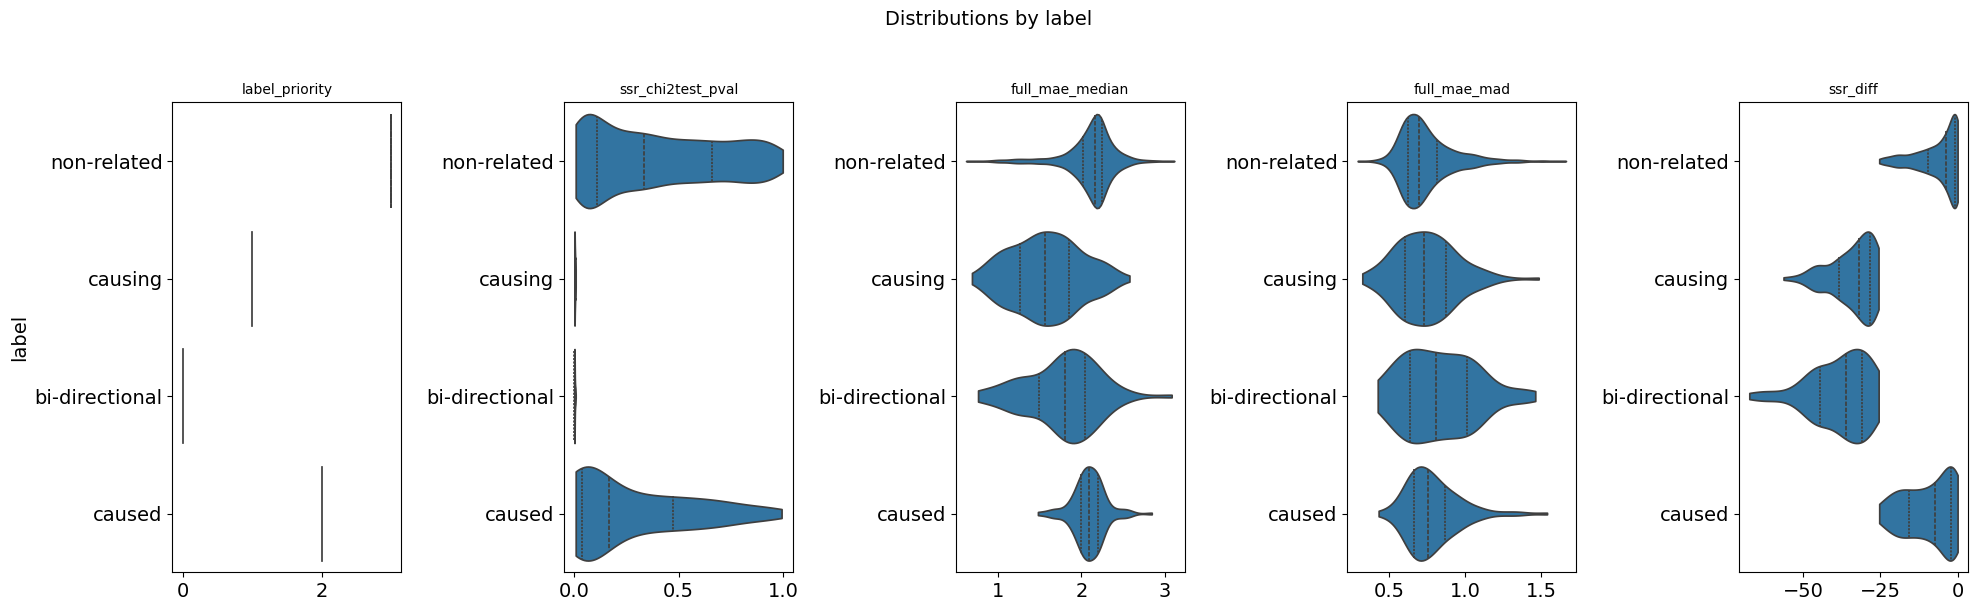

In [41]:
df = ranked_dvgs[1].copy()

num_cols = ['label_priority','ssr_chi2test_pval',
            'full_mae_median', 'full_mae_mad', 'ssr_diff']

fig, axes = plt.subplots(1, len(num_cols), figsize=(4 * len(num_cols), 6), sharey=False)

for ax, col in zip(axes, num_cols):
    sns.violinplot(data=df, y='label', x=col, ax=ax, cut=0, inner='quart', scale='width')
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('')
    ax.set_xlabel('')

axes[0].set_ylabel('label')
fig.suptitle('Distributions by label', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
plt.rcParams.update({'font.size': 14})
plot_ranked_distributions(ranked_dvgs[1].sort_values(by=['full_mae_median', 'ssr_chi2test_pval', 'ssr',
                                                      'full_mae_mad',
                                                      'label_priority'], 
                                                  ascending=[True, True, True, True, True]),
                          num_cols=['ssr_chi2test_pval', 'full_mae_median', 'full_mae_mad', 'ssr_diff'], color_col='label_priority')


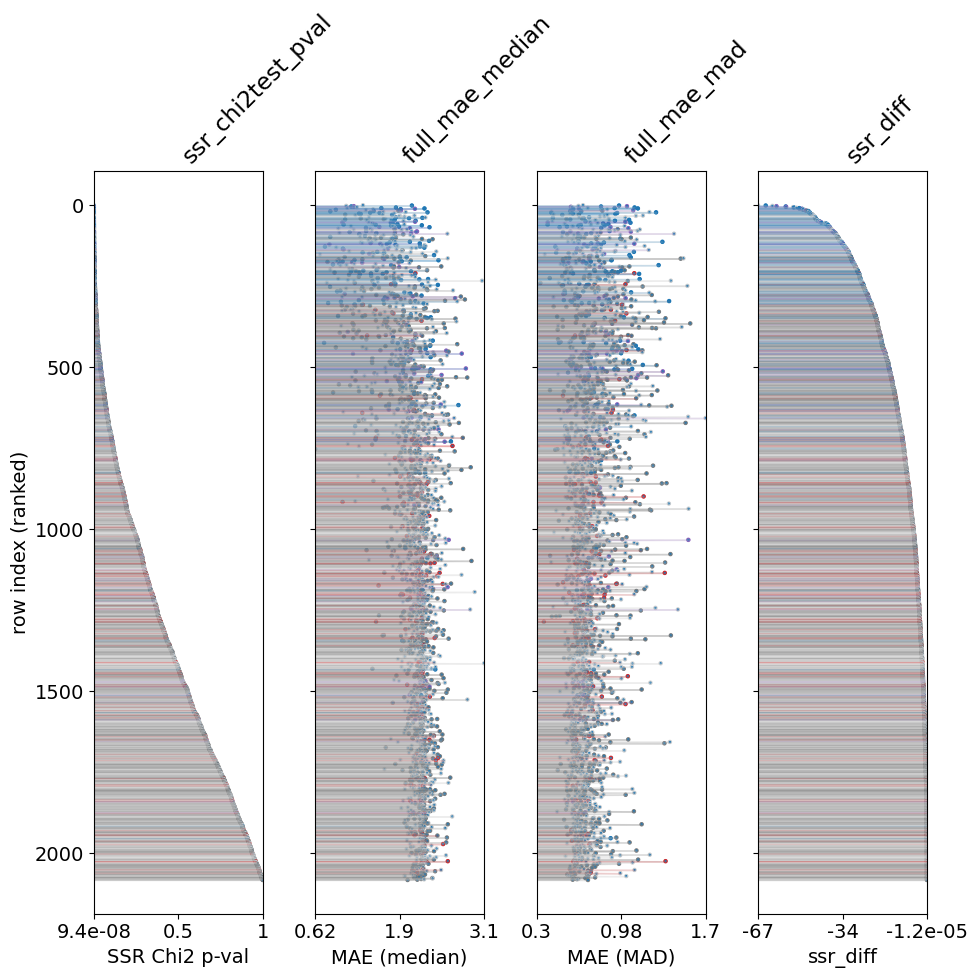

In [ ]:
plot_ranked_distributions(ranked_dvgs[1].sort_values(by=['ssr_chi2test_pval', 'full_mae_median','ssr',
                                                      'full_mae_mad',
                                                      'label_priority'], 
                                                  ascending=[True, True, True, True, True]),
                          num_cols=['ssr_chi2test_pval', 'full_mae_median', 'full_mae_mad', 'ssr_diff'], color_col='label_priority')

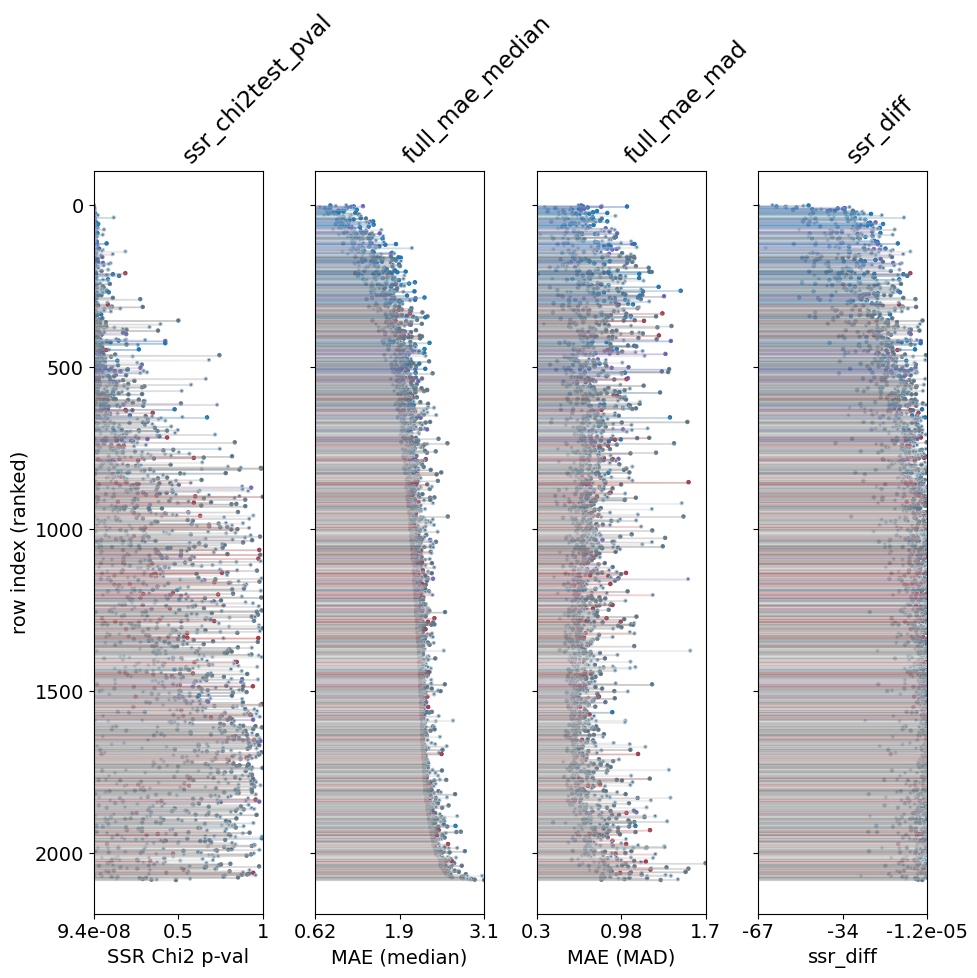

In [ ]:
# Rank used in the paper

ranked_dvgs[1]['norm_full_mae_median'] = ranked_dvgs[1]['full_mae_median'] / ranked_dvgs[1]['full_mae_median'].max()
ranked_dvgs[1]['norm_ssr'] = ranked_dvgs[1]['ssr'] / ranked_dvgs[1]['ssr'].max()
ranked_dvgs[1]['sum_norm_mae_ssr'] = ranked_dvgs[1]['norm_full_mae_median'] + ranked_dvgs[1]['norm_ssr']
ranked_dvgs[1]['rank_ssr_mae'] = ranked_dvgs[1]['sum_norm_mae_ssr'].rank(method='average', ascending=True)
plot_ranked_distributions(ranked_dvgs[1].sort_values(by=['rank_ssr_mae', 'ssr_chi2test_pval', 'full_mae_median', 'ssr',
                                                      'full_mae_mad',
                                                      'label_priority'],
                                                  ascending=[True, True, True, True, True, True]),
                          num_cols=['ssr_chi2test_pval', 'full_mae_median', 'full_mae_mad', 'ssr_diff'], color_col='label_priority')

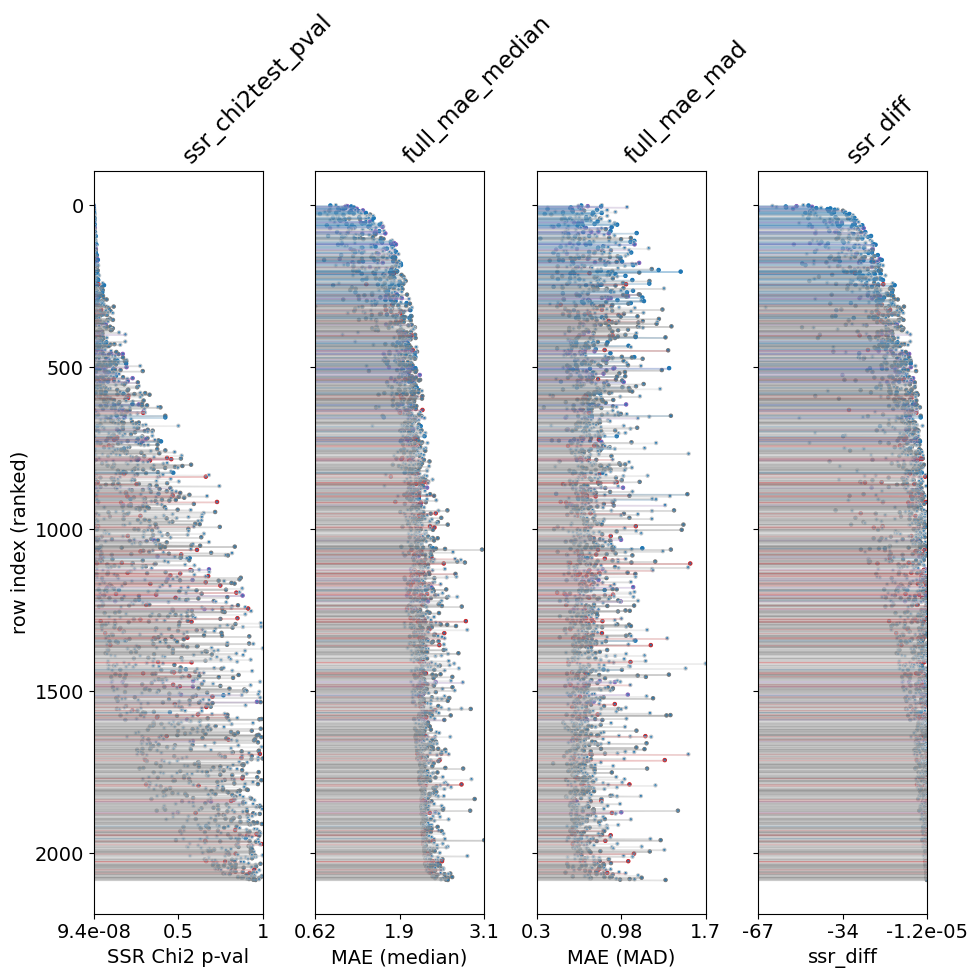

In [ ]:
# alternative rank that is better for non-parametric 
df = ranked_dvgs[1].copy()
df['rank_score'] = (df['norm_ssr'].rank() + df['norm_full_mae_median'].rank()) / 2
df = df.sort_values('rank_score')
plot_ranked_distributions(df,
                          num_cols=['ssr_chi2test_pval', 'full_mae_median', 'full_mae_mad', 'ssr_diff'], color_col='label_priority')

# export files

In [ ]:
ranked_df = df.sort_values(by=['rank_ssr_mae',
                                          'ssr_chi2test_pval', 'full_mae_median', 'full_mae_mad', 'ssr',
                                            'label_priority']).reset_index(drop=True)
ranked_df

,dvg,label,ssr_chi2test_pval,restr_mae_median,restr_mae_mad,full_mae_median,full_mae_mad,ssr,ssr_diff,label_priority,norm_full_mae_median,norm_ssr,sum_norm_mae_ssr,rank_ssr_mae,rank_score
0,PA_316_1832,bi-directional,6.914338e-07,2.207702,0.603624,1.074584,0.634652,105.098924,-61.655176,0,0.345005,0.630263,0.975268,1.0,26.5
1,PA_138_246,bi-directional,4.594307e-05,2.207702,0.603624,0.840275,0.657045,119.499124,-47.254976,0,0.269778,0.716619,0.986397,2.0,16.0
2,PB1_170_2024,bi-directional,2.673670e-05,2.207702,0.603624,0.921029,0.823002,117.438802,-49.315298,0,0.295705,0.704263,0.999968,3.0,16.0
3,PA_172_1938,bi-directional,9.408092e-08,2.207702,0.603624,1.321737,0.670980,99.353982,-67.400118,0,0.424356,0.595811,1.020167,4.0,62.5
4,PB1_77_121,bi-directional,1.167214e-06,2.207702,0.603624,1.186736,1.026445,106.713644,-60.040456,0,0.381013,0.639946,1.020959,5.0,41.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2079,PB2_185_216,non-related,5.685992e-01,2.207702,0.603624,2.866608,0.998557,165.473524,-1.280576,3,0.920351,0.992321,1.912672,2080.0,1802.5
2080,PB1_148_2137,non-related,2.896116e-01,2.207702,0.603624,2.926852,1.006536,162.417454,-4.336647,3,0.939693,0.973994,1.913687,2081.0,1590.0
2081,PB1_240_2061,non-related,3.719454e-01,2.207702,0.603624,2.907730,1.437806,163.648080,-3.106020,3,0.933554,0.981374,1.914928,2082.0,1664.0
2082,PA_179_1974,non-related,3.406557e-01,2.207702,0.603624,2.973948,0.820105,163.225467,-3.528633,3,0.954814,0.978839,1.933653,2083.0,1638.5


In [ ]:
ranked_df[ranked_df.dvg.isin(['PB2_269_2202', 'PB2_217_2204', 'PB2_129_2176'])]

,dvg,label,ssr_chi2test_pval,restr_mae_median,restr_mae_mad,full_mae_median,full_mae_mad,ssr,ssr_diff,label_priority,norm_full_mae_median,norm_ssr,sum_norm_mae_ssr,rank_ssr_mae,rank_score
262,PB2_217_2204,causing,0.001592,2.207702,0.603624,1.819617,0.463604,134.766947,-31.987153,1,0.584205,0.808178,1.392383,263.0,252.0
660,PB2_129_2176,non-related,0.258198,2.207702,0.603624,1.923942,0.869262,161.828379,-4.925721,3,0.617700,0.970461,1.588161,661.0,767.0
1781,PB2_269_2202,non-related,0.959041,2.207702,0.603624,2.237145,1.071294,166.743629,-0.010471,3,0.718256,0.999937,1.718194,1782.0,1805.5


In [ ]:
ranked_df[ranked_df.dvg == 'PB1_146_2056']

,dvg,label,ssr_chi2test_pval,restr_mae_median,restr_mae_mad,full_mae_median,full_mae_mad,ssr,ssr_diff,label_priority,norm_full_mae_median,norm_ssr,sum_norm_mae_ssr,rank_ssr_mae,rank_score
6,PB1_146_2056,causing,0.001988,2.207702,0.603624,0.686589,0.36181,135.833924,-30.920176,1,0.220436,0.814576,1.035012,7.0,77.5


In [ ]:
ranked_df.head(10)

,dvg,label,ssr_chi2test_pval,restr_mae_median,restr_mae_mad,full_mae_median,full_mae_mad,ssr,ssr_diff,label_priority,norm_full_mae_median,norm_ssr,sum_norm_mae_ssr,rank_ssr_mae,rank_score
0,PA_316_1832,bi-directional,6.914338e-07,2.207702,0.603624,1.074584,0.634652,105.098924,-61.655176,0,0.345005,0.630263,0.975268,1.0,26.5
1,PA_138_246,bi-directional,4.594307e-05,2.207702,0.603624,0.840275,0.657045,119.499124,-47.254976,0,0.269778,0.716619,0.986397,2.0,16.0
2,PB1_170_2024,bi-directional,2.673670e-05,2.207702,0.603624,0.921029,0.823002,117.438802,-49.315298,0,0.295705,0.704263,0.999968,3.0,16.0
3,PA_172_1938,bi-directional,9.408092e-08,2.207702,0.603624,1.321737,0.670980,99.353982,-67.400118,0,0.424356,0.595811,1.020167,4.0,62.5
4,PB1_77_121,bi-directional,1.167214e-06,2.207702,0.603624,1.186736,1.026445,106.713644,-60.040456,0,0.381013,0.639946,1.020959,5.0,41.0
5,PA_295_372,causing,3.676009e-06,2.207702,0.603624,1.148637,0.816981,110.421375,-56.332725,1,0.368781,0.662181,1.030962,6.0,35.0
6,PB1_146_2056,causing,1.988032e-03,2.207702,0.603624,0.686589,0.361810,135.833924,-30.920176,1,0.220436,0.814576,1.035012,7.0,77.5
7,PA_164_1989,causing,1.265988e-05,2.207702,0.603624,1.090037,0.709261,114.699398,-52.054702,1,0.349967,0.687836,1.037802,8.0,31.0
8,PB1_329_1996,bi-directional,3.836099e-06,2.207702,0.603624,1.186177,0.573257,110.563843,-56.190257,0,0.380833,0.663035,1.043869,9.0,41.5
9,PA_163_259,bi-directional,1.337845e-03,2.207702,0.603624,0.759903,0.447641,133.940148,-32.813952,0,0.243974,0.803220,1.047193,10.0,66.5


In [ ]:
ranked_df.rank_ssr_mae.max()

2084.0

In [ ]:
ranked_df['mae_median_diff'] = ranked_df['full_mae_median'] - ranked_df['restr_mae_median']

In [ ]:
selected_dvgs = ranked_df[ranked_df['label'].isin(['causing', 'bi-directional'])][['dvg', 'label', 'rank_ssr_mae', 'full_mae_median', 'full_mae_mad', 'ssr', 'ssr_chi2test_pval', 'ssr_diff', 'mae_median_diff']].reset_index(drop=True)
selected_dvgs[['dvg', 'label', 'full_mae_median', 'full_mae_mad', 'mae_median_diff', 'ssr', 'ssr_diff', 'rank_ssr_mae']].to_csv(f'{output_prefix}/selected_dvgs_lag1.csv', index=False)
ranked_df[['dvg', 'label', 'full_mae_median', 'full_mae_mad', 'mae_median_diff', 'ssr', 'ssr_diff', 'rank_ssr_mae']].to_csv(f'{output_prefix}/ranked_dvgs_lag1.csv', index=False)


KeyError: "['mae_median_diff'] not in index"

In [ ]:
selected_dvgs

,dvg,label,rank_ssr_mae,full_mae_median,full_mae_mad,ssr,ssr_chi2test_pval,ssr_diff,mae_median_diff
0,PA_316_1832,bi-directional,1.0,1.074584,0.634652,105.098924,6.914338e-07,-61.655176,-1.133118
1,PA_138_246,bi-directional,2.0,0.840275,0.657045,119.499124,4.594307e-05,-47.254976,-1.367428
2,PB1_170_2024,bi-directional,3.0,0.921029,0.823002,117.438802,2.673670e-05,-49.315298,-1.286673
3,PA_172_1938,bi-directional,4.0,1.321737,0.670980,99.353982,9.408092e-08,-67.400118,-0.885966
4,PB1_77_121,bi-directional,5.0,1.186736,1.026445,106.713644,1.167214e-06,-60.040456,-1.020967
...,...,...,...,...,...,...,...,...,...
241,PA_1944_1990,bi-directional,736.0,2.570870,1.406616,130.290223,6.069972e-04,-36.463877,0.363168
242,PB1_199_2110,causing,761.0,2.398188,0.731962,140.320387,4.910775e-03,-26.433713,0.190486
243,PB1_192_2129,bi-directional,826.0,2.480331,1.045770,138.205496,3.224656e-03,-28.548604,0.272629
244,PA_294_317,causing,962.0,2.575875,1.482551,136.495594,2.278306e-03,-30.258506,0.368173


In [ ]:
selected_dvgs[selected_dvgs.dvg.isin(['PB2_269_2202', 'PB2_217_2204', 'PB2_129_2176'])]

,dvg,label,rank_ssr_mae,full_mae_median,full_mae_mad,ssr,ssr_chi2test_pval,ssr_diff,mae_median_diff
167,PB2_217_2204,causing,263.0,1.819617,0.463604,134.766947,0.001592,-31.987153,-0.388086


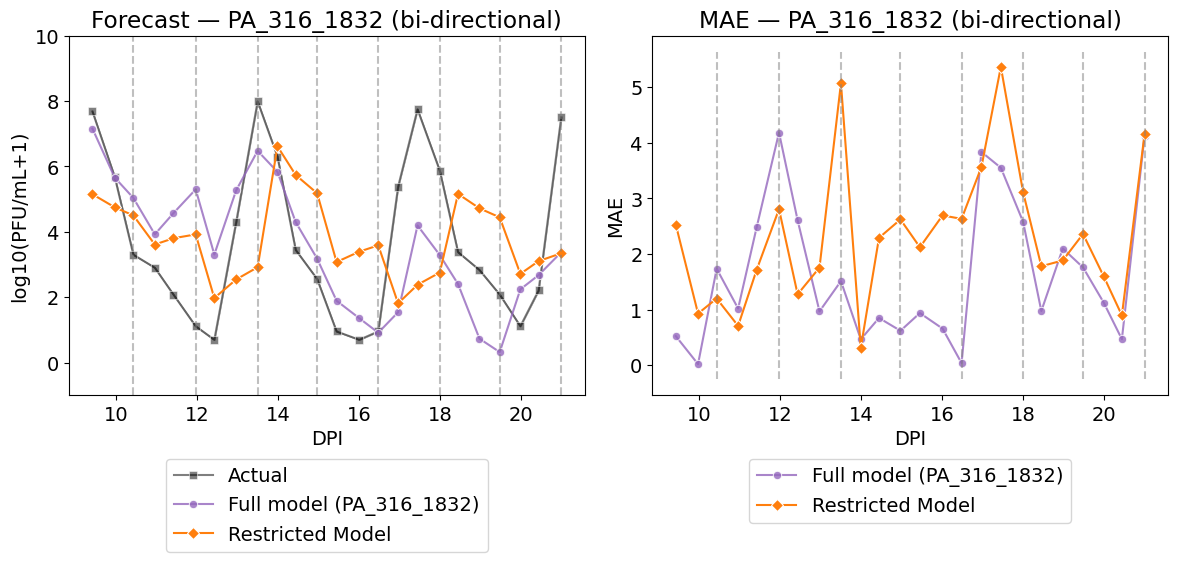

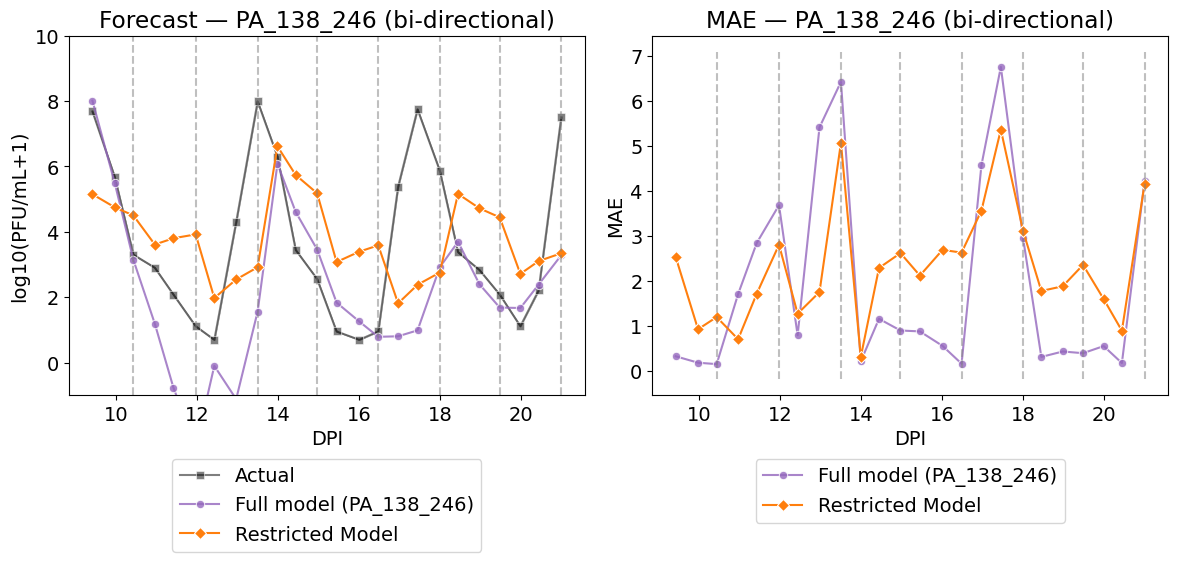

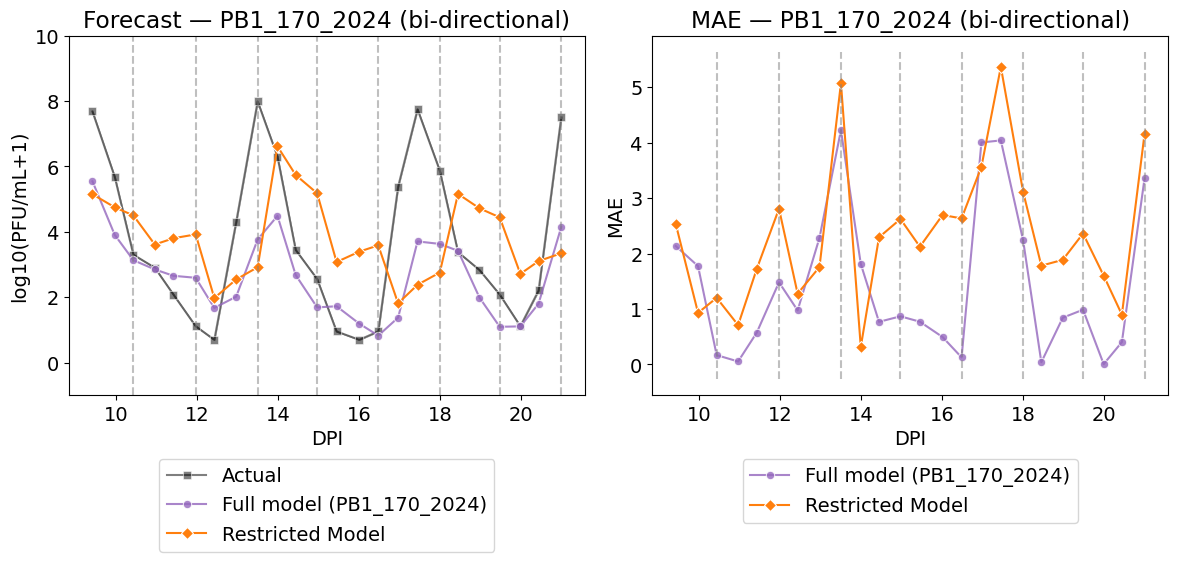

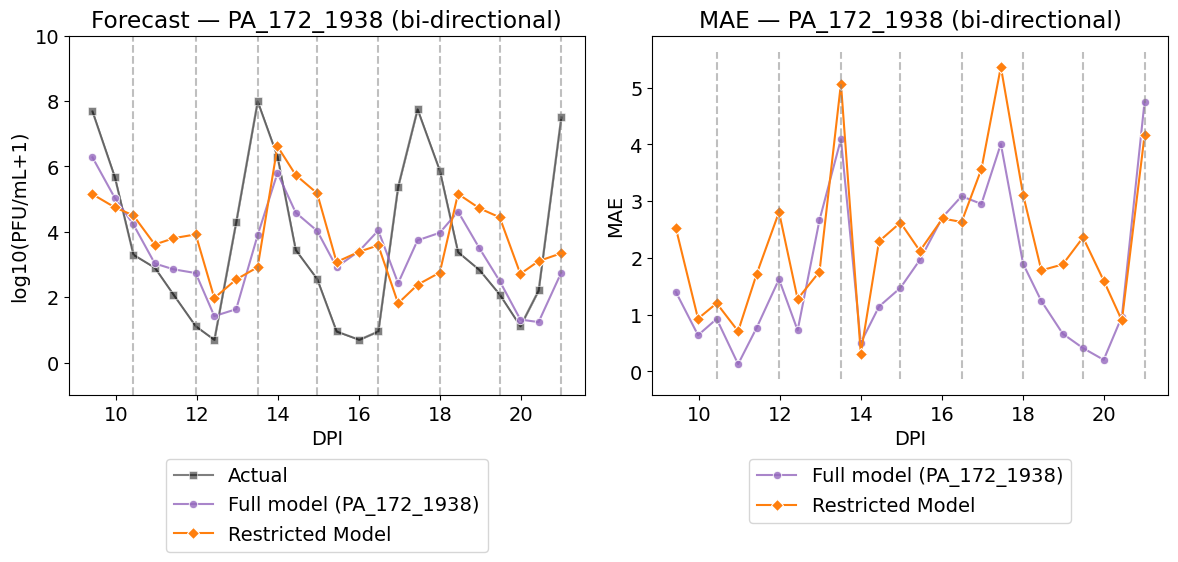

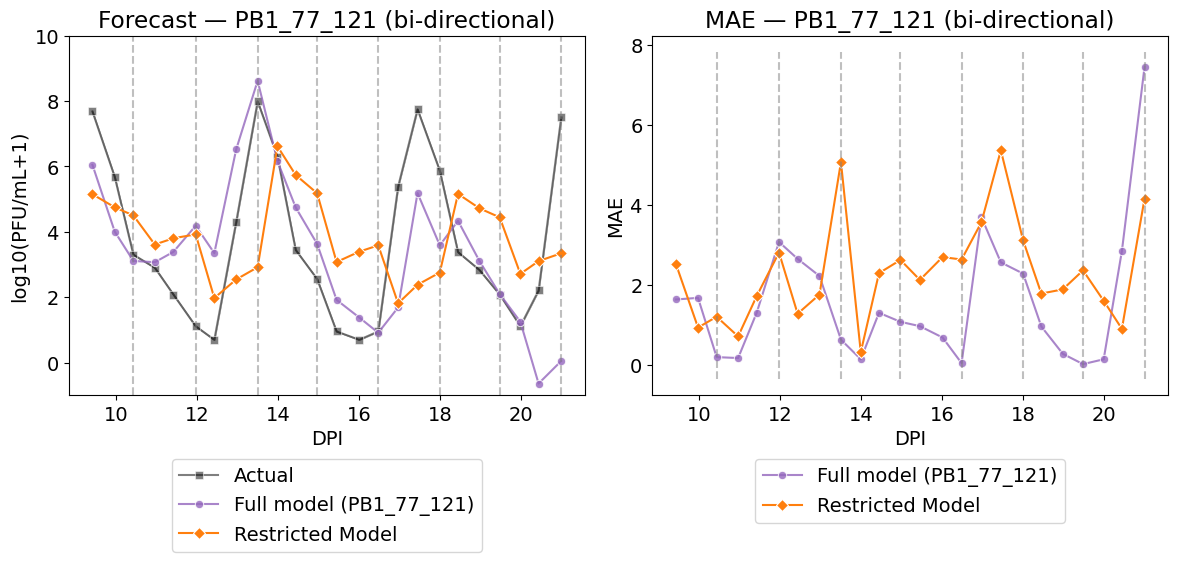

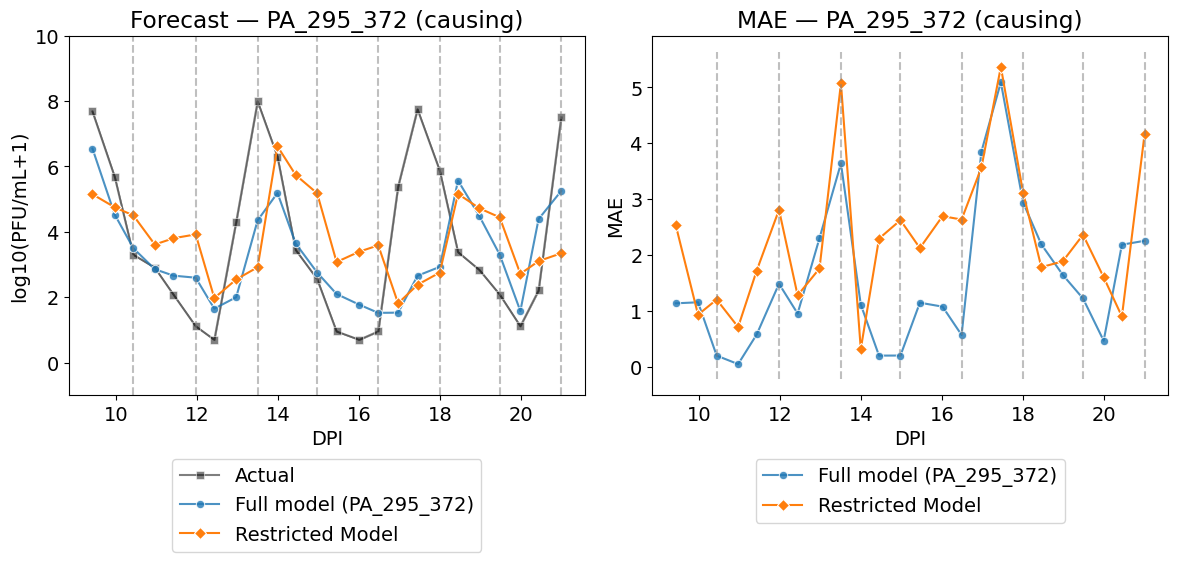

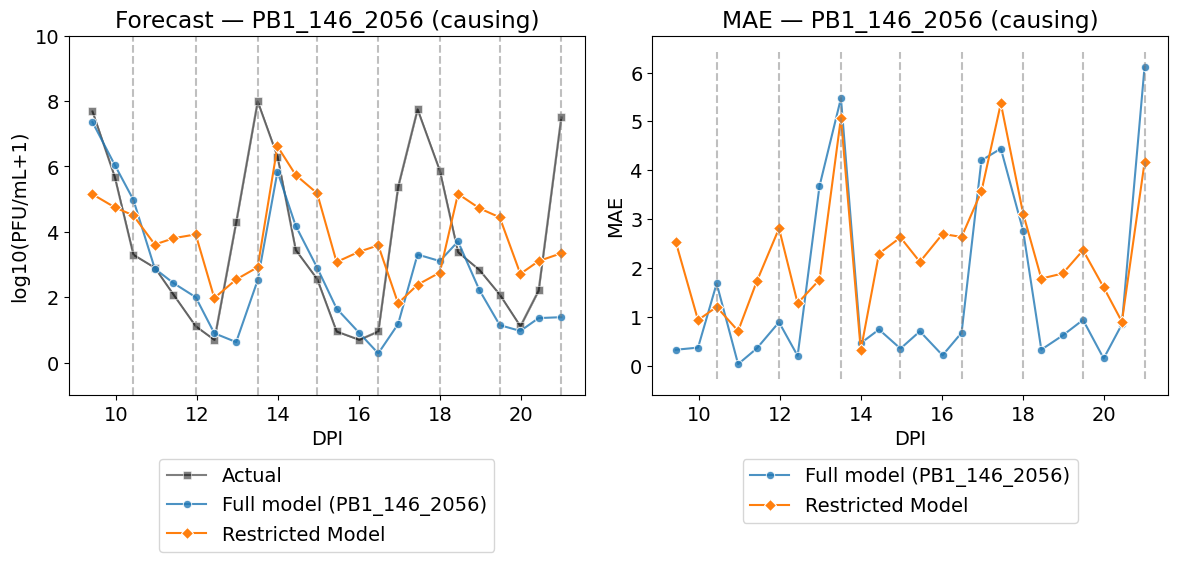

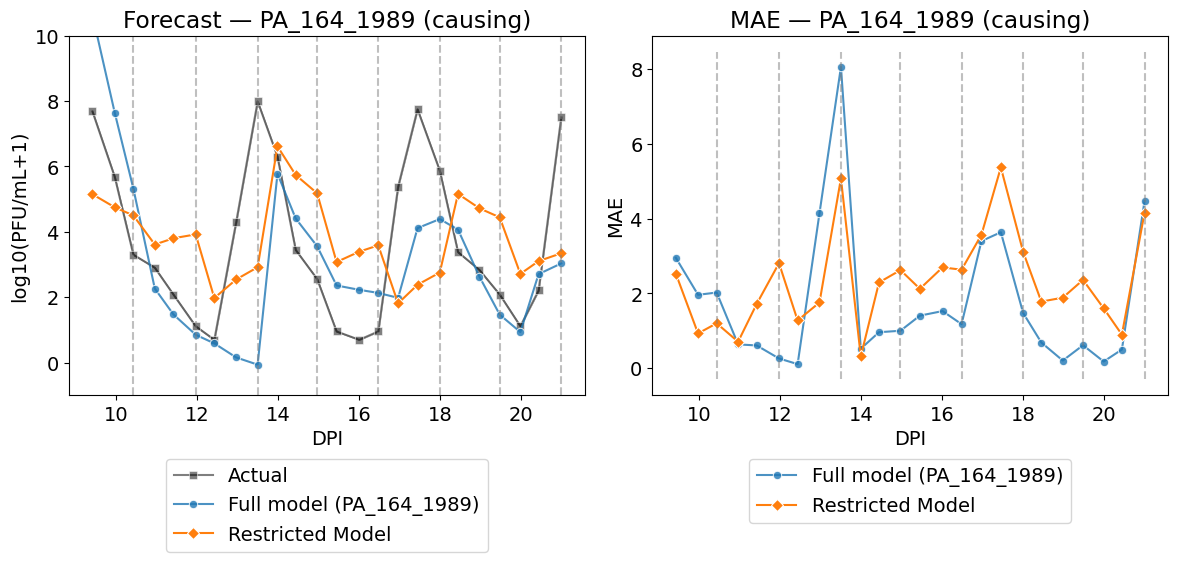

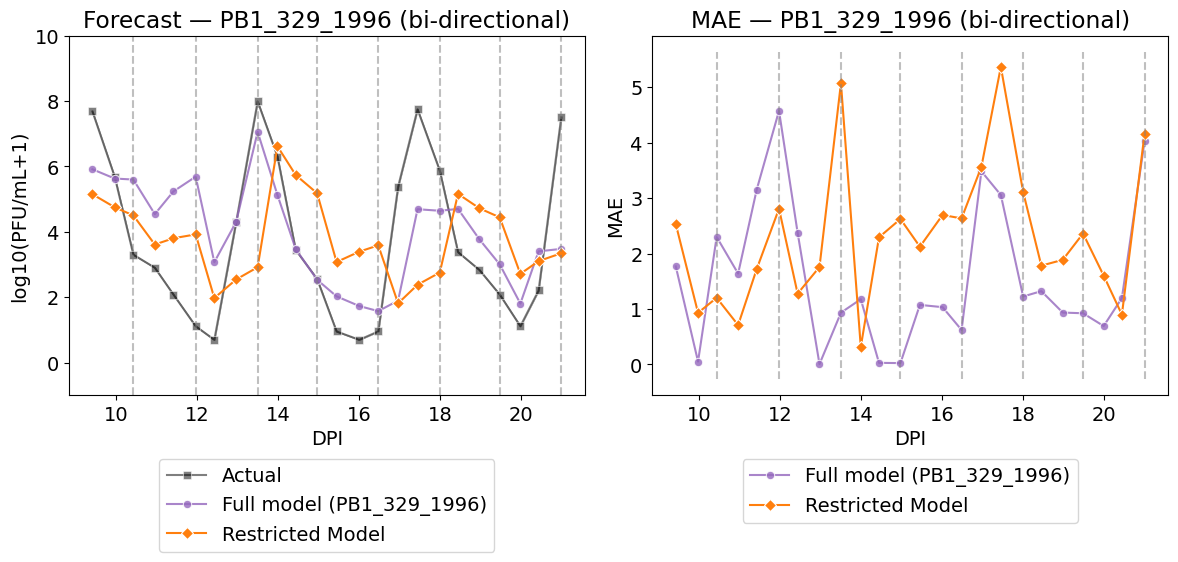

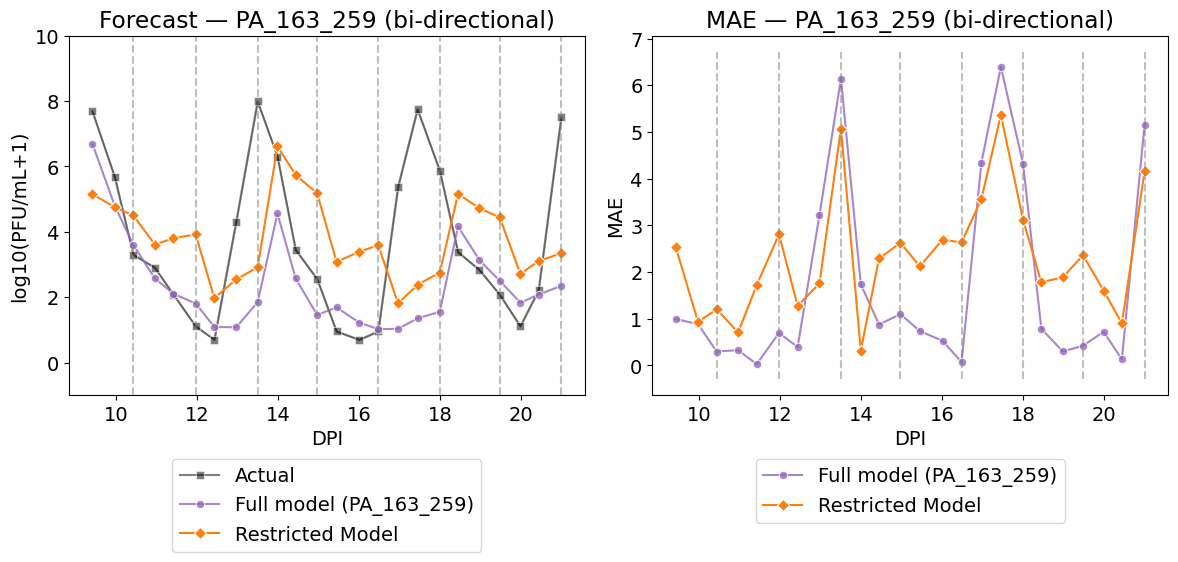

In [ ]:
for dvg in selected_dvgs['dvg'].head(10):
  plot_dvg_forecast_and_mae(dvg_id=dvg, lag=1, figsize=(12,6))